In [1]:
import numpy as np
import csv
from tf_model import make_model
from tf_data import Batch
import time
import torch
import torch.nn as nn
from torch.autograd import Variable
import os
from tqdm import tqdm
import random
import shutil
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize


all pass EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_features=128, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=128, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0-1): 2 x SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (norm): LayerNorm()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=

/home/cnelabai/PycharmProjects/UNetpp1D/tf_model.py:342: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(p)


In [2]:
def read_train_data(file_name):
    with open(file_name, 'r', newline='') as f:
        lines = csv.reader(f)
        data = []
        for line in lines:
            data.append(line)

    data = np.array(data).astype(np.float64)
    return data


def cut_data(file_name):
    with open(file_name, 'r', newline='') as f:
        lines = csv.reader(f)
        raw_data = []
        for line in lines:
            raw_data.append(line)
    raw_data = np.array(raw_data).astype(np.float)
    total = int(len(raw_data[0]) / 1024)
    for i in range(total):
        table = raw_data[:, i * 1024:(i + 1) * 1024]
        filename = './temp2/' + str(i) + '.csv'
        with open(filename, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerows(table)
    return total


def glue_data(file_name, total, output):
    gluedata = 0
    for i in range(total):
        file_name1 = file_name + 'output{}.csv'.format(str(i))
        with open(file_name1, 'r', newline='') as f:
            lines = csv.reader(f)
            raw_data = []
            for line in lines:
                raw_data.append(line)
        raw_data = np.array(raw_data).astype(np.float)
        #print(i)
        if i == 0:
            gluedata = raw_data
        else:
            smooth = (gluedata[:, -1] + raw_data[:, 1]) / 2
            gluedata[:, -1] = smooth
            raw_data[:, 1] = smooth
            gluedata = np.append(gluedata, raw_data, axis=1)
    #print(gluedata.shape)
    filename2 = output
    with open(filename2, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(gluedata)
        print("GLUE DONE!" + filename2)


def save_data(data, filename):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(data)

def dataDelete(path):
    try:
        shutil.rmtree(path)
    except OSError as e:
        print(e)
    else:
        print("The directory is deleted successfully")
        
def eeg_fft(eeg_data_1, eeg_data_2):
    # Function to perform FFT and get frequency bins
    def perform_fft(signal, fs):
        n = len(signal)
        freq = np.fft.fftfreq(n, 1/fs)
        fft_values = np.fft.fft(signal)
        return freq, fft_values

    # Generate sample EEG data: 30 channels, 1024 time points, 256 Hz sampling rate
    fs = 256.0  # Sampling frequency (Hz)

    # Initialize empty arrays to store FFT differences
    fft_diff = np.zeros_like(eeg_data_1, dtype=complex)
    eeg1_fft = np.zeros_like(eeg_data_1, dtype=complex)
    eeg2_fft = np.zeros_like(eeg_data_1, dtype=complex)

    # Loop through each channel to compute FFT and find the difference
    for i in range(eeg_data_1.shape[0]):
        freq, fft_values_1 = perform_fft(eeg_data_1[i, :], fs)
        _, fft_values_2 = perform_fft(eeg_data_2[i, :], fs)

        # Compute the difference in frequency domain
        eeg1_fft[i, :] = np.abs(fft_values_1)
        eeg2_fft[i, :] = np.abs(fft_values_2)
        
    fft_diff = eeg2_fft-eeg1_fft
    return np.abs(fft_diff[:,0:201])

In [3]:
def subsequent_mask(size):
    # "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
    return torch.from_numpy(subsequent_mask) == 0

def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 30, 1).fill_(start_symbol).type_as(src.data)
    for i in range(max_len-1):
        out = model.decode(memory, src_mask, 
                           Variable(ys), 
                           Variable(subsequent_mask(ys.size(-1))
                                    .type_as(src.data)))
        prob = model.generator(out)
        prob = prob[:,-1,:].unsqueeze(1)
        ys = torch.cat([ys, prob.permute(0, 2, 1)], dim=2)
    ys = ys[:,:,1:max_len]
    return ys

def greedy_decode2(model, src, src_mask, max_len, start_symbol):
    window = 64
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 30, window).fill_(start_symbol).type_as(src.data)
    for i in range(5):
        out = model.decode(memory, src_mask, 
                           Variable(ys), 
                           Variable(subsequent_mask(ys.size(-1))
                                    .type_as(src.data)))
        prob = model.generator(out)
        #prob = prob[:,256*i+1,:].unsqueeze(1)
        print("greedy_decode1: ", prob.shape)
        if i ==0:
            ys = prob.permute(0, 2, 1)
        else:
            ys = torch.cat([ys, prob.permute(0, 2, 1)], dim=2)
    print("greedy_decode2: ", ys.shape)
    ys = ys[:,:,1:max_len]
    return ys

def decode_data(noisy_data, clean_data, std_num=1, mode=5):
    noisy_data = torch.FloatTensor(noisy_data)
    noisy_data = noisy_data.unsqueeze(0)
    clean_data = torch.FloatTensor(clean_data)
    clean_data = clean_data.unsqueeze(0)
    #print(data.shape)
    model = make_model(30, 30, N=2)
    
    #total_params = sum(p.numel() for p in model.parameters())
    #print(f'{mode} Total number of parameters in model: {total_params}')
    
    if mode == "Trans_a":
        resumeLoc = './0908_RealEEG' + '/modelsave/checkpoint.pth.tar'
    elif mode == "Trans_b":
        resumeLoc = './0916_RealEEG' + '/modelsave/checkpoint.pth.tar'
    elif mode == "Trans_c":
        resumeLoc = './0915_RealEEG' + '/modelsave/checkpoint.pth.tar'

        
    checkpoint = torch.load(resumeLoc, map_location='cpu')
    #start_epoch = checkpoint['epoch']
    model.load_state_dict(checkpoint['state_dict'])
    criterion = nn.MSELoss()
    model.eval() 
    with torch.no_grad():
        src = noisy_data
        tgt = clean_data
        batch = Batch(src, tgt, 0)
        # --- Greedy Decode ---
        #decode = greedy_decode2(model, batch.src, batch.src_mask, max_len=1024, start_symbol=1)
        #print("decode_data1: ", decode.shape)
        #print("decode_data2: ", batch.trg.shape)
        # --- General Decode ---
        ys = torch.ones(1, 30, 1023).fill_(1).type_as(batch.src.data)
        ys_mask = subsequent_mask(ys.size(-1)).type_as(src.data)
        if mode == "Trans_a":
            out = model.forward(batch.src, batch.trg, batch.src_mask, batch.trg_mask)
        elif mode == "Trans_b":
            out = model.forward(batch.src, ys, batch.src_mask, ys_mask)
        elif mode == "Trans_c":
            out = model.forward(batch.src, batch.src[:,:,1:], batch.src_mask, batch.trg_mask)
        #print(batch.trg.shape)
        decode = model.generator(out)
        loss = criterion(decode, batch.trg.permute(0, 2, 1))
        #print(batch.ntokens)
        #loss = criterion(decode, batch.trg)
        
    
    decode_src_att_map = []
    decode_src_att_map.append(torch.squeeze(model.decoder.layers[0].src_attn.attn.data))
    decode_src_att_map.append(torch.squeeze(model.decoder.layers[1].src_attn.attn.data))
    decode_src_att_map = np.array(decode_src_att_map)
    #print(decode_src_att_map.shape)
    decode = decode[0,:,:]
    decode = torch.transpose(decode, 0, 1)
    decode = decode.cpu().detach().numpy()
    return decode, (loss.item()*batch.ntokens)/batch.ntokens, decode_src_att_map

def plotSignal(source, target, signal, ch):
    titlename = "Channel plot with mode" + str(3)

    #print("draw:", mode, signal.shape)

    # Selecting one specific channel (e.g., the first channel)
    channel_to_plot1 = source[ch, 2:1024]
    channel_to_plot2 = target[ch, 2:1024]
    channel_to_plot3 = signal[ch, 2:1024]

    # Create a new figure
    plt.figure(figsize=(10, 6))

    # Plot the selected channel
    plt.plot(channel_to_plot1, 'k')
    plt.plot(channel_to_plot2, 'b')
    plt.plot(channel_to_plot3, 'r')

    # Add labels and title
    plt.xlabel('Time or Sample Index')
    plt.ylabel('Amplitude')
    plt.title(titlename)

    # Save the figure to a file
    plt.savefig(titlename+'.png')

def mean_squared_error(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

def save_data(data, filename):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(data)
        
def createFolder(path, data_mode):
    if not os.path.isdir(path):
        os.mkdir(path)
    for i in range(3):
        if not os.path.isdir(path+data_mode[i]):
            os.mkdir(path+data_mode[i])

In [5]:

'''
folder_path = './Real_EEG/test/Brain/'
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

for i, csv_file in enumerate(tqdm(csv_files, desc="Reading CSV files")):
    #file_name2 = './Real_EEG/test/Brain' + '{:03d}.csv'.format(i+1)
    #print(csv_file)

    noisy_data = read_train_data(folder_path+csv_file)

    # --- pre-processing ---
    data_avg = np.average(noisy_data)
    data_std = np.std(noisy_data)
    noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)

    # --- decode ---
    start_time = time.time()
    decode, loss, att_map = decode_data(noisy_data, noisy_data, mode='Trans_c') # Trans_a, Trans_b, Trans_c
    take_time = time.time() - start_time
    #print("take_time: ", take_time)

    # --- save data ---
    save_name2 = './0915_RealEEG/testRaw/Brain/' + csv_file
    #print(save_name2)
    save_data(decode, save_name2)
'''    
    
    
def createFolder(path):
    if not os.path.isdir(path):
        os.mkdir(path)

# ---
model_mode = 'Trans_c' # Trans_a, Trans_b, Trans_c
folder = './raw_test/'
data_mode = ["Eye", "Muscle"]
createFolder(folder)

for i in range(2):
    print(data_mode[i])
    createFolder(folder + data_mode[i] + '/' + model_mode)
    allFileList = os.listdir(folder + data_mode[i] + '/noise') # ./Real_EEG/test/

    for file in tqdm(allFileList):
        #print(file)
        
        file_name1 = folder + data_mode[i] + '/noise/' + file
        # ./Real_EEG/test/
        # --- read data ---
        noisy_data = read_train_data(file_name1)
        #print(noisy_data.shape)

        # --- pre-processing ---
        data_avg = np.average(noisy_data)
        data_std = np.std(noisy_data)
        noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)


        # --- decode ---
        decode, loss, att_map = decode_data(noisy_data, noisy_data, mode=model_mode) # Trans_a, Trans_b, Trans_c

        #print(decode.shape)
        noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
        decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)
        
        # --- save decode ---

        save_name1 = folder + data_mode[i] + '/' + model_mode + '/' + file
        save_data(decode, save_name1)
        

Muscle


  0%|                                                  | 0/2534 [00:00<?, ?it/s]/tmp/ipykernel_26858/2449152877.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoi

IndexError: list index out of range

In [4]:
# --- parameters ---
#folder = './1011_RealEEG/'
#data_mode = ["ChannelNoise", "Eye", "Heart", "LineNoise", "Muscle", "Other"]
#createFolder('./'+folder+'/testMSE/', data_mode)

# ---
model_mode = 'Trans_c' # Trans_a, Trans_b, Trans_c
folder = './0916_RealEEG/'
data_mode = ["Eye", "Heart", "Muscle"]
createFolder('./'+folder+'/testEDN/', data_mode)

for i in range(6):
    print(data_mode[i])
    allFileList = os.listdir("../ArtifactRemoval/GCTNet/data/test_EDN/" + data_mode[i]) # , ./Real_EEG/test/
    mse_clde = []
    mse_clno = []
    mse_clde_freq = np.zeros((30,201))
    total = 0
    best_ratio = 100
    for file in allFileList:
        total = total + 1
        file_name1 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Brain' + '/' + file # ./Real_EEG/test/
        file_name2 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + data_mode[i] + '/' + file # ./Real_EEG/test/
        # --- read data ---
        clean_data = read_train_data(file_name1)
        noisy_data = read_train_data(file_name2)
        #print(data.shape)

        # --- pre-processing ---
        data_avg = np.average(noisy_data)
        data_std = np.std(noisy_data)
        noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)


        # --- decode ---
        decode, loss, att_map = decode_data(noisy_data, clean_data, mode=model_mode)
        #print(decode.shape)
        clean_data = (clean_data - np.mean(clean_data)) / np.std(clean_data+ 1e-10)
        noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
        decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)
        decode = np.hstack((decode, np.zeros((30, 1))))
        
        # --- MSE ---
        mse_clde_temp = []
        mse_clno_temp = []
        for idx in range(30):
            #mse_clde_temp.append(mean_squared_error(clean_data[idx], decode[idx]))
            mse_clde_temp.append(mean_squared_error(noisy_data[idx], decode[idx]))
            mse_clno_temp.append(mean_squared_error(clean_data[idx], noisy_data[idx]))
            mse_ratio = mean_squared_error(clean_data[idx], decode[idx]) / mean_squared_error(clean_data[idx], noisy_data[idx])
            is_lower = mse_ratio < best_ratio
            if is_lower:
                best_ratio = mse_ratio
                save_name1 = folder + 'testEDN/' + data_mode[i] + '/Best_brain.csv'
                save_name2 = folder + 'testEDN/' + data_mode[i] + '/Best_noise.csv'
                save_name3 = folder + 'testEDN/' + data_mode[i] + '/Best_decode.csv'
                save_data(clean_data, save_name1)
                save_data(noisy_data, save_name2)
                save_data(decode, save_name3)
                print(file, idx, best_ratio)
            
        mse_clde.append(mse_clde_temp)
        mse_clno.append(mse_clno_temp)
        mse_clde_freq = mse_clde_freq + eeg_fft(clean_data, decode)

        # --- save csv file ---
        #save_name = './0915_RealEEG/testing/' + data_mode[i] + '/' + file
        #save_data(decode, save_name)
        #print(save_name, loss)
    save_name1 = folder + 'testEDN/' + data_mode[i] + '/mse_clde.csv'
    save_name2 = folder + 'testEDN/' + data_mode[i] + '/mse_clno.csv'
    save_name3 = folder + 'testEDN/' + data_mode[i] + '/mse_clde_freq.csv'
    save_data(mse_clde, save_name1)
    save_data(mse_clno, save_name2)
    save_data(mse_clde_freq/total, save_name3)

# --- plot & MSE ---
#decode = np.hstack((decode, np.zeros((30, 1))))
#print("MSE: ", mean_squared_error(data[0], decode[0]))
#plotSignal(data, decode)

Eye


/home/cnelabai/PycharmProjects/UNetpp1D/tf_model.py:342: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(p)


1280.csv 0 0.8698318776284044
1280.csv 2 0.825327765800114
1280.csv 3 0.8064352819313138
1280.csv 29 0.8043619672197331
839.csv 0 0.7360381765018706
839.csv 2 0.7284292274077201
1581.csv 0 0.7211225500514344
1581.csv 2 0.6939190887567056
684.csv 27 0.6505558594516387
24.csv 29 0.6379366123353815
1692.csv 29 0.6373712448427166
1272.csv 22 0.6237762018149847
1772.csv 27 0.6110251783644333
1772.csv 29 0.6083243177211478
1098.csv 3 0.5954187196019619
1098.csv 24 0.5844973288859622
1098.csv 27 0.5685925807831744
1098.csv 29 0.5668003771380288
919.csv 0 0.5561966766067953
1459.csv 29 0.5509678923011994
1270.csv 0 0.3565130111662392
Heart
1280.csv 0 0.7064234051495302
1455.csv 0 0.6969685295229467
222.csv 0 0.6245201430921338
781.csv 0 0.5943423324114747
976.csv 0 0.5523849974888706
1376.csv 0 0.537509858776719
Muscle
1280.csv 0 1.3521667365022032
1280.csv 1 1.34272043327718
1280.csv 22 1.2364365159583455
839.csv 0 1.0414965090976833
839.csv 1 1.0356020898157228
839.csv 22 1.015429986847221
1

IndexError: list index out of range

take_time:  0.14282560348510742
(2, 8, 1023, 1024)
MSE:  1.1372725171550973
[1.0898384705889448, 1.1370062935653873, 1.0143023154396957, 0.9229561261565811, 0.9582399897233951, 1.0492401940711593, 1.4317088410028245, 1.1985785863363456, 1.1456651197695535, 1.0089382946127383, 1.1331957213115995, 1.6456906213475413, 1.3103623655797436, 1.2168801759792085, 0.9518941423546574, 1.0506724191782357, 1.3378828172332782, 1.1372725171550973, 1.0884116106230937, 0.962866417737464, 0.9966927578642744, 1.2671790651896635, 0.942997241235206, 0.9887248092518681, 0.8953965400906454, 0.9497684669775538, 0.9887507642334714, 0.8484197157717386, 0.9629461717452448, 0.8396795208078902]


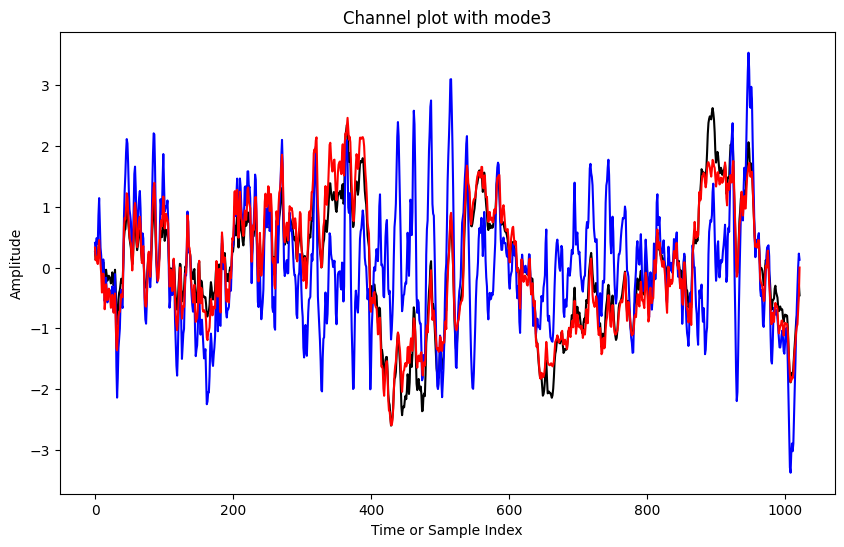

In [6]:
from scipy.io import savemat
#segament = '493_69'
#file_name1 = './Real_EEG/test/' + 'Brain' + '/' + segament + '.csv'
#file_name2 = './Real_EEG/test/' + 'Other' + '/' + segament + '.csv'

segament = '33'
file_name1 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Brain' + '/' + segament + '.csv'
file_name2 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Eye' + '/' + segament + '.csv'


clean_data = read_train_data(file_name1)
noisy_data = read_train_data(file_name2)
#print(data.shape)

# --- pre-processing ---
data_avg = np.average(noisy_data)
data_std = np.std(noisy_data)
#noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)
#clean_data = np.array((clean_data - data_avg) / data_std).astype(np.float64)
noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)


# --- decode ---
start_time = time.time()
decode, loss, att_map = decode_data(noisy_data, clean_data, mode='Trans_c') # Trans_a, Trans_b, Trans_c
take_time = time.time() - start_time
print("take_time: ", take_time)

print(att_map.shape)
#clean_data = (clean_data - np.mean(clean_data)) / (np.std(clean_data)+ 1e-10)
#noisy_data = (noisy_data - np.mean(noisy_data)) / (np.std(noisy_data)+ 1e-10)
#decode = (decode - np.mean(decode)) / (np.std(decode)+ 1e-10)
#decode = np.hstack((decode, np.zeros((30, 1))))
clean_data = (clean_data - np.mean(clean_data)) / np.std(clean_data+ 1e-10)
noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)
decode = np.hstack((decode, np.zeros((30, 1))))


# --- plot & MSE ---
mse_tmp = []
for i in range(30):
    #mse_tmp.append(mean_squared_error(noisy_data[i], decode[i]))
    mse_tmp.append(mean_squared_error(clean_data[i], decode[i]))
ch=17
print("MSE: ", mean_squared_error(clean_data[ch], decode[ch]))
print(mse_tmp)
plotSignal(noisy_data, clean_data, decode, ch=ch)

# --- save data ---
savemat('./testFig/signal_viz/Other/' + segament + '_att_map.mat', {'data': att_map})
save_data(noisy_data, './testFig/signal_viz/Other/' + segament + '_noise.csv')
save_data(decode,     './testFig/signal_viz/Other/' + segament + '_Trans_c.csv')
save_data(clean_data, './testFig/signal_viz/Other/' + segament + '_clean.csv')

In [75]:
file_name1 = './Real_EEG/test/' + 'Brain' + '/' + '460_51.csv'
file_name2 = './Real_EEG/test/' + 'Eye' + '/' + '460_51.csv'


clean_data = read_train_data(file_name1)
noisy_data = read_train_data(file_name2)
print(clean_data.shape)

y_mean = np.mean(clean_data)
print(y_mean)
y_std = np.std(clean_data, axis=0, keepdims=True)

# Normalize y
y1 = (clean_data - y_mean) / (y_std + 1e-10)
print(np.mean(y1))
#y1 = (clean_data - np.mean(clean_data)) / np.std(clean_data+ 1e-10)
#y2 = (clean_data - np.mean(clean_data, axis=0, keepdims=True)) / (np.std(clean_data, axis=0, keepdims=True)+ 1e-10)
y2 = (clean_data - np.mean(clean_data, axis=0)) / (np.std(clean_data, axis=0)+ 1e-10)

result = np.array_equal(y1, y2)
print(result)

(30, 1024)
0.08951822437571613
0.0035420674760290797
False


float64


NameError: name 'freq' is not defined

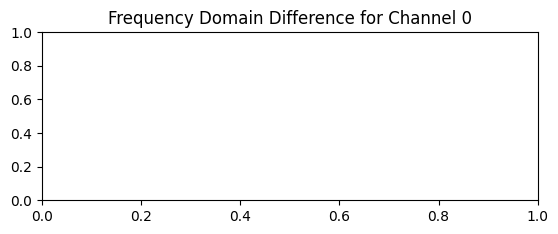

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def eeg_fft(eeg_data_1, eeg_data_2):
    # Function to perform FFT and get frequency bins
    def perform_fft(signal, fs):
        n = len(signal)
        freq = np.fft.fftfreq(n, 1/fs)
        fft_values = np.fft.fft(signal)
        return freq, fft_values

    # Generate sample EEG data: 30 channels, 1024 time points, 256 Hz sampling rate
    fs = 256.0  # Sampling frequency (Hz)

    # Initialize empty arrays to store FFT differences
    fft_diff = np.zeros_like(eeg_data_1, dtype=complex)
    eeg1_fft = np.zeros_like(eeg_data_1, dtype=complex)
    eeg2_fft = np.zeros_like(eeg_data_1, dtype=complex)

    # Loop through each channel to compute FFT and find the difference
    for i in range(eeg_data_1.shape[0]):
        freq, fft_values_1 = perform_fft(eeg_data_1[i, :], fs)
        _, fft_values_2 = perform_fft(eeg_data_2[i, :], fs)

        # Compute the difference in frequency domain
        eeg1_fft[i, :] = np.abs(fft_values_1)
        eeg2_fft[i, :] = np.abs(fft_values_2)
        
    fft_diff = eeg2_fft-eeg1_fft
    return np.abs(fft_diff[:,0:201])
    

file_name1 = './Real_EEG/test/' + 'Brain' + '/' + '460_51.csv'
file_name2 = './Real_EEG/test/' + 'Eye' + '/' + '460_51.csv'


eeg_data_1 = read_train_data(file_name1) # clean
eeg_data_2 = read_train_data(file_name2) # noisy

mse_clde_freq = np.zeros((30,201))
for i in range(2):
    dif_fft = eeg_fft(eeg_data_1, eeg_data_2)
    mse_clde_freq = mse_clde_freq + dif_fft
    #mse_clde_freq.append(dif_fft)
print(mse_clde_freq.dtype)
save_data(mse_clde_freq/2, './1010_RealEEG/mse_clde_freq.csv')
      

# Visualization of difference for one channel (e.g., channel 0)
plt.figure()
plt.subplot(2, 1, 1)
plt.title('Frequency Domain Difference for Channel 0')
plt.plot(freq[0:201], eeg1_fft[0, 0:201])
plt.plot(freq[0:201], eeg2_fft[0, 0:201])
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.title('Time Domain Difference for Channel 0')
plt.plot(time_domain_diff[0, :].real)  # Taking only the real part
plt.xlabel('Time Points')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


In [9]:
data1 = read_train_data('./MetaPreTrain/Lane_keeping/3_ICA/10_10.csv')
data2 = read_train_data('./MetaPreTrain/Lane_keeping/3_ICA/10_14.csv')
concatenated_array = np.concatenate((data1, data2), axis=1)
print(concatenated_array.shape)
plotSignal(concatenated_array, data1)


(30, 2048)


TypeError: plotSignal() missing 2 required positional arguments: 'signal' and 'ch'

torch.Size([1024, 128])
torch.Size([1024, 1])
torch.Size([64])
torch.Size([1024, 64])


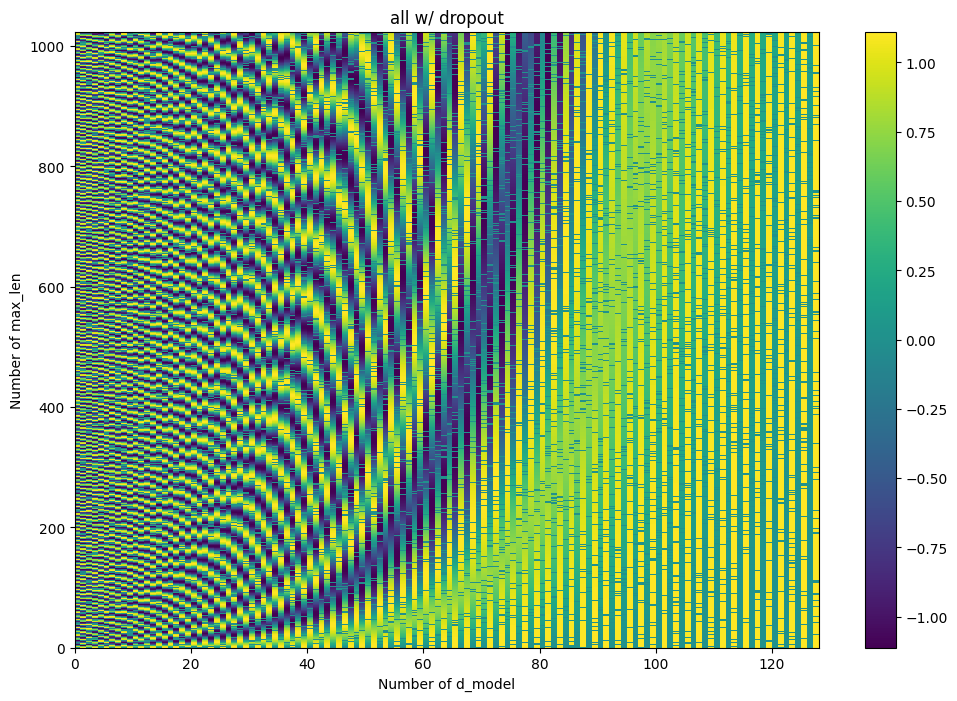

In [104]:
import matplotlib.pyplot as plt
import torch
import math
from torch.autograd import Variable


# Initialization
d_model = 128
max_len = 1024
pe = torch.zeros(max_len, d_model)
print(pe.shape)
position = torch.arange(0, max_len).unsqueeze(1).float()
print(position.shape)
# Scaling term
div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
print(div_term.shape)
temp = torch.cos(position * div_term)
print(temp.shape)
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

dropout = nn.Dropout(p=0.1)
x = Variable(pe, requires_grad=False)
pe = dropout(x)

# Visualization
plt.figure(figsize=(12, 8))
#plt.plot(div_term) 
#plt.plot(temp[5,:])
#plt.pcolormesh(temp, cmap='viridis')
plt.pcolormesh(pe, cmap='viridis')
plt.xlabel('Number of d_model')
#plt.xlim((0, 512))
#plt.ylim((0, 50))
plt.ylabel('Number of max_len')
plt.title('all w/ dropout')
plt.colorbar()
plt.show()


torch.Size([1024, 128])
torch.Size([1024, 128]) torch.Size([1024, 128]) torch.Size([1024, 128])
torch.Size([8, 1024, 16]) torch.Size([8, 1024, 16]) torch.Size([8, 1024, 16])
attention1:  torch.Size([8, 1024, 16]) torch.Size([8, 1024, 16]) torch.Size([8, 1024, 16]) torch.Size([1, 1024, 1024])
attention2:  torch.Size([8, 1024, 16]) torch.Size([8, 16, 1024]) torch.Size([8, 1024, 1024])
attention3:  torch.Size([8, 1024, 16]) torch.Size([8, 16, 1024]) torch.Size([8, 1024, 1024])
torch.Size([8, 1024, 16]) torch.Size([8, 1024, 1024])
torch.Size([1024, 128])
torch.Size([1024, 128])


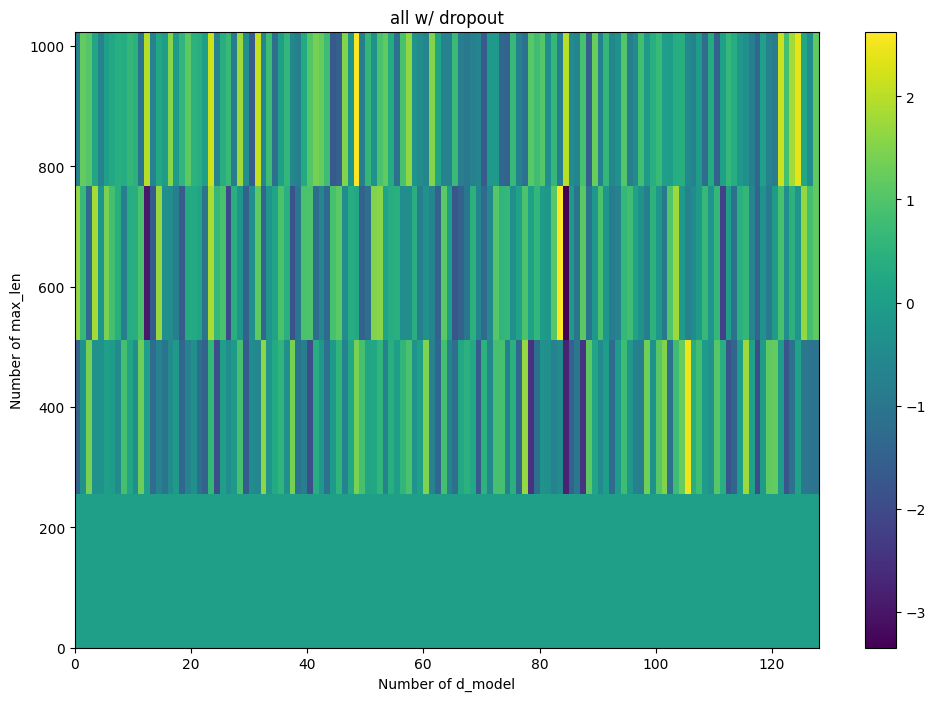

In [217]:
import matplotlib.pyplot as plt
import torch
import math, copy
from torch.autograd import Variable
import torch.nn.functional as F


def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    print("attention1: ", query.shape, key.shape, value.shape, mask.shape)
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    print("attention2: ", query.shape, key.transpose(-2, -1).shape, scores.shape)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
        print("attention3: ", query.shape, key.transpose(-2, -1).shape, scores.shape)
    p_attn = F.softmax(scores, dim = -1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

# Embedding
embedding = nn.Embedding(1000, 128, padding_idx=0)
data = torch.linspace(0, 4, steps=1024, dtype=torch.long)
data_emb = embedding(data)

# input data
T = 2 * np.pi  # One complete cycle
sample_rate = 1024
length = T * 128  # 30 cycles
x = torch.linspace(0, length, steps=sample_rate * 128, dtype=torch.float32)
sine_waves = torch.zeros((128, 1024))
for i in range(128):
    sine_waves[i] = torch.sin(x[i*sample_rate:(i+1)*sample_rate] + i*T/30.0)
sine_waves = sine_waves.transpose(0, 1)
print(sine_waves.shape)

query = sine_waves
key = sine_waves
value = sine_waves
print(query.shape, key.shape, value.shape)

# step 1.
linears = clones(nn.Linear(128, 128), 4)
query, key, value = [l(x).view( 8, 128//8, -1).transpose(1, 2) for l, x in zip(linears, (query, key, value))]
print(query.shape, key.shape, value.shape)

# step 2.
size = 1024
attn_shape = (1, size, size)
subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
subsequent_mask = torch.from_numpy(subsequent_mask) == 0

x, attn = attention(query, key, value, mask=subsequent_mask, dropout=nn.Dropout(p=0.1))
print(x.shape, attn.shape)

# step 3.
x = x.transpose(1, 2).contiguous().view(-1, 8 * 16)
print(x.shape)

temp = linears[-1](x)
print(temp.shape)

# Visualization
plt.figure(figsize=(12, 8))
#plt.pcolormesh(sine_waves, cmap='viridis')
#plt.pcolormesh(query[0,:,:].detach().numpy(), cmap='viridis')
#plt.pcolormesh(attn[0,:,:].detach().numpy(), cmap='viridis')
#plt.plot(x[:,1].detach().numpy())#, cmap='viridis')
#plt.plot(temp[:,1].detach().numpy())#, cmap='viridis')
#plt.pcolormesh(temp.detach().numpy(), cmap='viridis')
plt.pcolormesh(data_emb.detach().numpy(), cmap='viridis')
plt.xlabel('Number of d_model')
#plt.xlim((0, 512))
#plt.ylim((0, 50))
plt.ylabel('Number of max_len')
plt.title('all w/ dropout')
plt.colorbar()
plt.show()

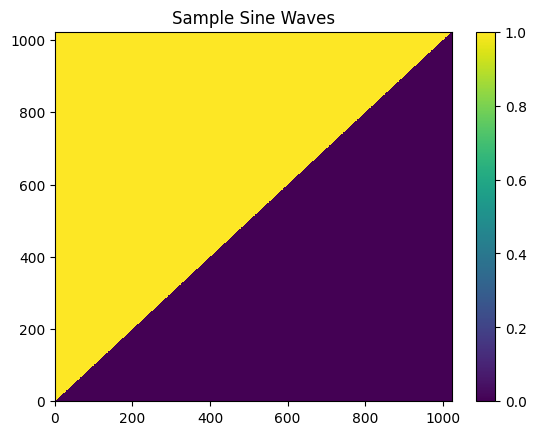

In [168]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the sine wave
size = 1023
attn_shape = (1, size, size)
subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
subsequent_mask = torch.from_numpy(subsequent_mask) == 0

plt.pcolormesh(subsequent_mask[0,:,:], cmap='viridis')
plt.title("Sample Sine Waves")
plt.colorbar()
plt.show()


In [177]:
import torch

# Scores tensor
scores = torch.tensor([[0.1, 0.8, 0.3], 
                       [0.7, 0.5, 0.2], 
                       [0.6, 0.4, 0.1]])

print("Original Scores:")
print(scores)

# Create a mask where scores are less than 0.5
size = 3
attn_shape = (1, size, size)
subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
mask = torch.from_numpy(subsequent_mask) == 0


#mask = scores < 0.5
#print("\nMask (Scores < 0.5):")
print(mask)

# Use masked_fill to replace the values where the mask is True
masked_scores = scores.masked_fill(mask == 0, -1)
#masked_scores = scores.masked_fill(mask, -1e9)

print("\nMasked Scores:")
print(masked_scores)


Original Scores:
tensor([[0.1000, 0.8000, 0.3000],
        [0.7000, 0.5000, 0.2000],
        [0.6000, 0.4000, 0.1000]])
tensor([[[ True, False, False],
         [ True,  True, False],
         [ True,  True,  True]]])

Masked Scores:
tensor([[[ 0.1000, -1.0000, -1.0000],
         [ 0.7000,  0.5000, -1.0000],
         [ 0.6000,  0.4000,  0.1000]]])


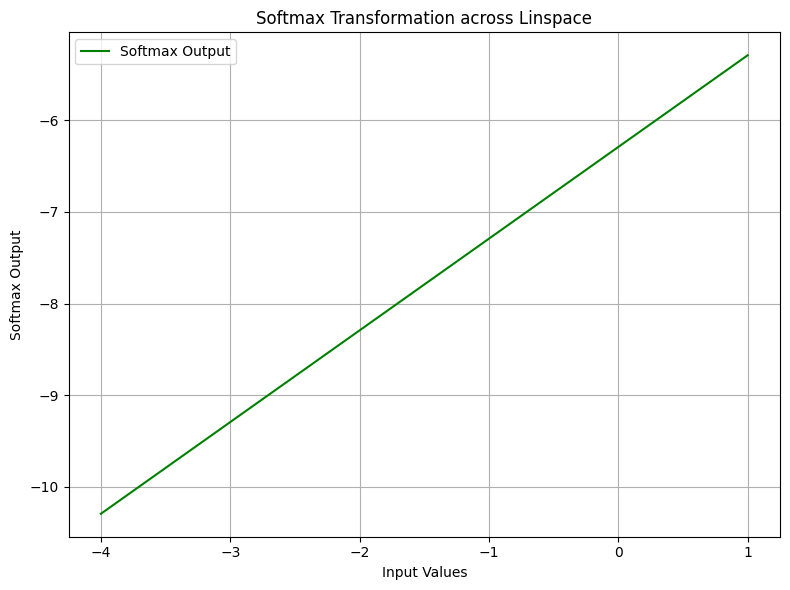

In [205]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Creating a linspace of values
x = torch.linspace(-4, 1, 1000)
#print(x)

# Applying softmax
y = F.log_softmax(x, dim=0).numpy()
#print(y)

# 
#m = nn.Sigmoid()
#y = m(x)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Softmax Output', color='green')

plt.title('Softmax Transformation across Linspace')
plt.xlabel('Input Values')
plt.ylabel('Softmax Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [215]:
embedding = nn.Embedding(1000, 128, padding_idx=0)
data = torch.linspace(0, 4, steps=1024, dtype=torch.long)
data_emb = embedding(data)
print(data_emb.shape)

torch.Size([1024, 128])


In [132]:
# Input string array
string_array = ['25_4_20.csv']

# Split the string by underscores
parts = string_array[0].split('_')
print(parts)
# Extract the numeric part and remove the '.csv' extension
numeric_part = parts[-1].split('.')[0]
print(numeric_part)
# Update the numeric part by adding 4 to it
new_numeric_part = str(int(numeric_part) + 4)
print(new_numeric_part)
# Replace the old numeric part with the updated one
parts[-1] = new_numeric_part + '.csv'
print(parts[-1])
# Join the parts back together with underscores and assign it to the array
string_array = '_'.join(parts)
print(parts)
# Resulting updated string
print(string_array)


['25', '4', '20.csv']
20
24
24.csv
['25', '4', '24.csv']
25_4_24.csv


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset, Subset
import numpy as np

# Create synthetic dataset
X = np.random.rand(100, 10)  # 100 samples, 10 features
y = np.random.randint(0, 2, 100)  # 100 labels

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Create a PyTorch dataset
dataset = TensorDataset(X, y)

# Calculate the length of each split
#total_length = len(dataset)
#split_length = total_length // 5  # assuming total_length is exactly divisible by 5
#lengths = [split_length]*5
#print(lengths)

# Randomly split dataset into 5 parts
#subsets = random_split(dataset, lengths)

# Calculate the size of a single subset
subset_size = len(dataset) // 5

# Create the subsets
subsets = [Subset(dataset, list(range(i * subset_size, (i + 1) * subset_size))) for i in range(5)]


# Now you can create a DataLoader for each subset (or fold)
dataloaders = [DataLoader(subset, batch_size=16, shuffle=True) for subset in subsets]

# Example: Access the DataLoader of the first fold
first_fold_loader = dataloaders[0]


# Neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(10, 1)
    
    def forward(self, x):
        return self.fc(x)

# Loop through each fold
fold = 0
for i in range(5):
    print(f"Fold {i}")
    train_loader = dataloaders[i]
    model = SimpleNN()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training
    epochs = 10
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                outputs = model(batch_x).squeeze()
                val_loss += criterion(outputs, batch_y).item()
        
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1}, Validation Loss: {val_loss}")
        
        # Save the model and results
        #torch.save(model.state_dict(), f"model_fold_{fold}_epoch_{epoch+1}.pth")

Fold 0
Epoch 1, Validation Loss: 0.7242013216018677
Epoch 2, Validation Loss: 0.7255701124668121
Epoch 3, Validation Loss: 0.7264561653137207
Epoch 4, Validation Loss: 0.7275756299495697
Epoch 5, Validation Loss: 0.7288343906402588
Epoch 6, Validation Loss: 0.7300201058387756
Epoch 7, Validation Loss: 0.7313230335712433
Epoch 8, Validation Loss: 0.7327042818069458
Epoch 9, Validation Loss: 0.7339979410171509
Epoch 10, Validation Loss: 0.735380083322525
Fold 1
Epoch 1, Validation Loss: 0.8094881474971771
Epoch 2, Validation Loss: 0.8068355917930603
Epoch 3, Validation Loss: 0.8041970133781433
Epoch 4, Validation Loss: 0.8017636239528656
Epoch 5, Validation Loss: 0.799617737531662
Epoch 6, Validation Loss: 0.7977156043052673
Epoch 7, Validation Loss: 0.795778751373291
Epoch 8, Validation Loss: 0.793806254863739
Epoch 9, Validation Loss: 0.7920364141464233
Epoch 10, Validation Loss: 0.7903954684734344
Fold 2
Epoch 1, Validation Loss: 0.7260333299636841
Epoch 2, Validation Loss: 0.72644546

In [4]:
model = make_model(30, 30, N=2)
resumeLoc = './1010_RealEEG' + '/modelsave/checkpoint.pth.tar'
checkpoint = torch.load(resumeLoc, map_location='cpu')
#start_epoch = checkpoint['epoch']
model.load_state_dict(checkpoint['state_dict'])

state = {'epoch': 0,
                 'subfold': 0,
                 'arch': str(model),
                 'state_dict': model.state_dict(),
                 'lossTr': 0.000296,
                 'lossTs': 0.000934,
                 'lossVal': 0.000124,
                 ' lr': 0.0003}
torch.save(state, resumeLoc)
print(model)

EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_features=128, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=128, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0-1): 2 x SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (norm): LayerNorm()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_